# 🏠 Egypt House Price Prediction — XGBoost Regression



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Egypt_Houses_Price.csv', encoding='latin-1')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (27361, 12)


,Type,Price,Bedrooms,Bathrooms,Area,Furnished,Level,Compound,Payment_Option,Delivery_Date,Delivery_Term,City
0,Duplex,4000000,3,3,400,No,7,Unknown,Cash,Ready to move,Finished,Nasr City
1,Apartment,4000000,3,3,160,No,10+,Unknown,Cash,Ready to move,Finished,Camp Caesar
2,Apartment,2250000,3,2,165,No,1,Unknown,Cash,Ready to move,Finished,Smoha
3,Apartment,1900000,3,2,230,No,10,Unknown,Cash,Ready to move,Finished,Nasr City
4,Apartment,5800000,2,3,160,No,Ground,Eastown,Cash,Ready to move,Semi Finished,New Cairo - El Tagamoa


##  Data Cleaning

In [2]:
# Convert numeric columns (stored as strings)
numeric_cols = ['Price', 'Bedrooms', 'Bathrooms', 'Area']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=numeric_cols, inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

# Clean Type duplicates
df['Type'] = df['Type'].str.strip().str.lower()
df['Type'] = df['Type'].replace({'standalone villa': 'stand alone villa'})

print(f"Shape after cleaning: {df.shape}")
print(f"Price range: {df['Price'].min():,.0f} — {df['Price'].max():,.0f} EGP")

Shape after cleaning: (24809, 12)
Price range: 30,000 — 205,000,000 EGP


##  Exploratory Data Analysis

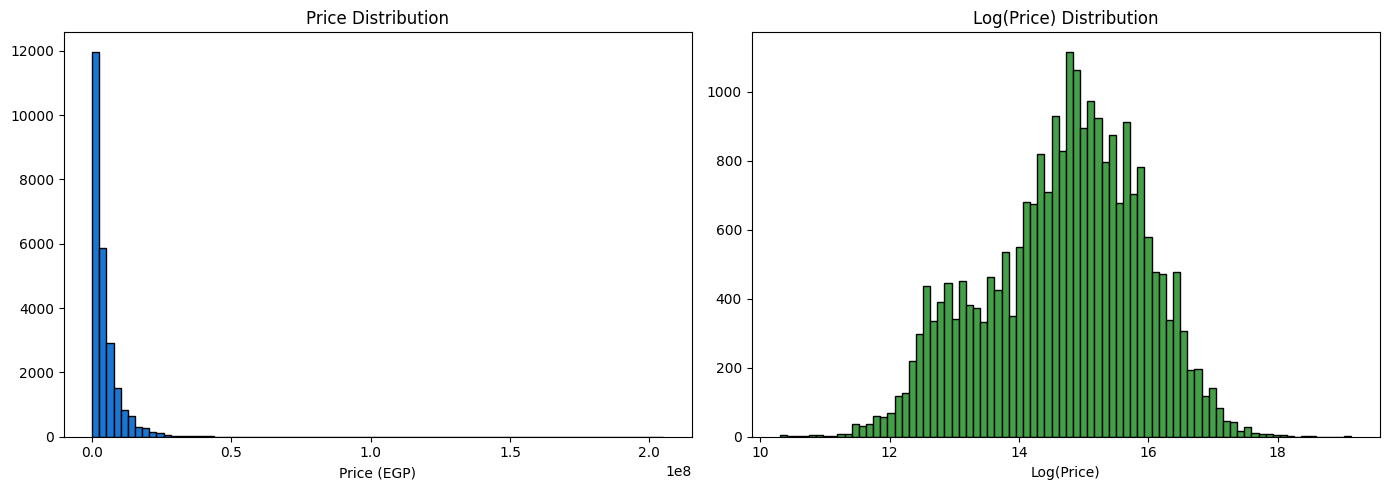

Type: 8 unique values
Furnished: 3 unique values
Level: 14 unique values
Compound: 555 unique values
Payment_Option: 4 unique values
Delivery_Date: 10 unique values
Delivery_Term: 5 unique values
City: 178 unique values


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Price'], bins=80, color='#1976D2', edgecolor='black')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (EGP)')

axes[1].hist(np.log1p(df['Price']), bins=80, color='#43A047', edgecolor='black')
axes[1].set_title('Log(Price) Distribution')
axes[1].set_xlabel('Log(Price)')
plt.tight_layout()
plt.show()

# Categorical overview
for col in df.select_dtypes(include=['object', 'string']).columns:
    print(f"{col}: {df[col].nunique()} unique values")

##  Feature Engineering

In [4]:
# Clean Level → numeric
def clean_level(val):
    val = str(val).strip().lower()
    if val in ['ground', 'g']: return 0
    elif val == 'highest': return 15
    elif val.startswith('10'): return 10
    try: return int(val)
    except: return np.nan

df['Level_num'] = df['Level'].apply(clean_level)
df['Level_num'] = df['Level_num'].fillna(df['Level_num'].median())
df.drop(columns=['Level'], inplace=True)

# Numeric features
df['Rooms_Total'] = df['Bedrooms'] + df['Bathrooms']
df['Area_per_Room'] = df['Area'] / df['Rooms_Total'].replace(0, 1)
df['Bed_Bath_ratio'] = df['Bedrooms'] / df['Bathrooms'].replace(0, 1)
df['Area_sq'] = df['Area'] ** 2
df['Area_log'] = np.log1p(df['Area'])

# Target
df['Price_log'] = np.log1p(df['Price'])

# Remove extreme outliers
Q1, Q3 = df['Price'].quantile(0.01), df['Price'].quantile(0.99)
before = len(df)
df = df[(df['Price'] >= Q1) & (df['Price'] <= Q3)].reset_index(drop=True)
print(f"Outlier removal: {before} → {len(df)} rows")

Outlier removal: 24809 → 24338 rows


##  Multi-Level Target Encoding



In [5]:
cat_cols = ['Type', 'Furnished', 'Compound', 'Payment_Option', 'Delivery_Date', 'Delivery_Term', 'City']
global_mean = df['Price_log'].mean()

# String representations for combo keys
bed_s = df['Bedrooms'].astype(str)
bath_s = df['Bathrooms'].astype(str)
area_b = pd.qcut(df['Area'], q=100, labels=False, duplicates='drop').astype(str)
area_b2 = pd.qcut(df['Area'], q=30, labels=False, duplicates='drop').astype(str)
comp_s = df['Compound'].astype(str)
city_s = df['City'].astype(str)
type_s = df['Type'].astype(str)
furn_s = df['Furnished'].astype(str)
pay_s = df['Payment_Option'].astype(str)
deliv_s = df['Delivery_Term'].astype(str)
ddate_s = df['Delivery_Date'].astype(str)

new_feats = {}

def te(key, name):
    """Target encode: compute mean, median, count of Price_log per group."""
    grp = df.groupby(key)['Price_log']
    new_feats[name + '_m'] = key.map(grp.mean()).fillna(global_mean)
    new_feats[name + '_md'] = key.map(grp.median()).fillna(global_mean)
    new_feats[name + '_c'] = key.map(grp.count()).fillna(1)

# ── Single-column encoding ──
for col in cat_cols:
    te(df[col].astype(str), col)

# ── 2-way combinations ──
pairs = [
    (comp_s, type_s, 'CpTy'), (comp_s, bed_s, 'CpBd'), (comp_s, bath_s, 'CpBa'),
    (comp_s, area_b, 'CpAr'), (comp_s, area_b2, 'CpAr2'), (comp_s, furn_s, 'CpFu'),
    (comp_s, deliv_s, 'CpDl'), (comp_s, pay_s, 'CpPa'),
    (city_s, type_s, 'CtTy'), (city_s, bed_s, 'CtBd'), (city_s, area_b, 'CtAr'),
    (city_s, furn_s, 'CtFu'), (city_s, deliv_s, 'CtDl'),
    (type_s, bed_s, 'TyBd'), (type_s, area_b, 'TyAr'), (type_s, furn_s, 'TyFu'),
]
for s1, s2, name in pairs:
    te(s1 + '|' + s2, name)

# ── 3-way combinations ──
triples = [
    (comp_s, type_s, bed_s, 'CpTyBd'), (comp_s, type_s, bath_s, 'CpTyBa'),
    (comp_s, type_s, area_b, 'CpTyAr'), (comp_s, type_s, area_b2, 'CpTyAr2'),
    (comp_s, bed_s, area_b, 'CpBdAr'), (comp_s, bed_s, bath_s, 'CpBdBa'),
    (comp_s, type_s, furn_s, 'CpTyFu'), (comp_s, type_s, deliv_s, 'CpTyDl'),
    (city_s, type_s, bed_s, 'CtTyBd'), (city_s, type_s, area_b, 'CtTyAr'),
    (city_s, bed_s, area_b, 'CtBdAr'), (city_s, type_s, furn_s, 'CtTyFu'),
]
for s1, s2, s3, name in triples:
    te(s1 + '|' + s2 + '|' + s3, name)

# ── 4-way combinations ──
quads = [
    (comp_s, type_s, bed_s, bath_s, 'CpTyBdBa'),
    (comp_s, type_s, bed_s, area_b, 'CpTyBdAr'),
    (comp_s, type_s, bed_s, area_b2, 'CpTyBdAr2'),
    (comp_s, type_s, bath_s, area_b, 'CpTyBaAr'),
    (comp_s, bed_s, bath_s, area_b, 'CpBdBaAr'),
    (comp_s, type_s, bed_s, furn_s, 'CpTyBdFu'),
    (city_s, type_s, bed_s, bath_s, 'CtTyBdBa'),
    (city_s, type_s, bed_s, area_b, 'CtTyBdAr'),
]
for s1, s2, s3, s4, name in quads:
    te(s1 + '|' + s2 + '|' + s3 + '|' + s4, name)

# ── 5-way combinations ──
te(comp_s+'|'+type_s+'|'+bed_s+'|'+bath_s+'|'+area_b, 'CpTyBdBaAr')
te(comp_s+'|'+type_s+'|'+bed_s+'|'+bath_s+'|'+area_b2, 'CpTyBdBaAr2')
te(comp_s+'|'+type_s+'|'+bed_s+'|'+area_b+'|'+furn_s, 'CpTyBdArFu')
te(city_s+'|'+type_s+'|'+bed_s+'|'+bath_s+'|'+area_b, 'CtTyBdBaAr')

# ── 6-way combinations ──
te(comp_s+'|'+type_s+'|'+bed_s+'|'+bath_s+'|'+area_b+'|'+furn_s, 'CpTyBdBaArFu')
te(comp_s+'|'+type_s+'|'+bed_s+'|'+bath_s+'|'+area_b+'|'+deliv_s, 'CpTyBdBaArDl')

# Merge all new features
feat_df = pd.DataFrame(new_feats, index=df.index)
df = pd.concat([df, feat_df], axis=1)

# Interaction features
df['area_x_comp'] = df['Area'] * df['Compound_m']
df['area_x_city'] = df['Area'] * df['City_m']

print(f" Created {len(new_feats)} target-encoded features")
print(f"Total features: {len(df.columns) - 2}")

 Created 147 target-encoded features
Total features: 165


##  Label Encode & Train-Test Split

In [6]:
# Label encode original categorical columns
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# Split
features = [c for c in df.columns if c not in ['Price', 'Price_log']]
X = df[features]
y = df['Price_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Training set: (19470, 165)
Test set:     (4868, 165)


##  XGBoost Model Training

In [7]:
model = XGBRegressor(
    n_estimators=5000,
    max_depth=6,
    learning_rate=0.02,
    subsample=0.85,
    colsample_bytree=0.25,
    min_child_weight=1,
    reg_alpha=0.01,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=100
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=200
)

print(f" Best iteration: {model.best_iteration}")

[0]	validation_0-rmse:1.12615	validation_1-rmse:1.11022
[200]	validation_0-rmse:0.38601	validation_1-rmse:0.42882
[400]	validation_0-rmse:0.35609	validation_1-rmse:0.42689
[415]	validation_0-rmse:0.35454	validation_1-rmse:0.42685
 Best iteration: 315


##  Evaluation

In [8]:
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

r2 = r2_score(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae = mean_absolute_error(y_actual, y_pred)
mape = np.mean(np.abs((y_actual - y_pred) / y_actual)) * 100


print(f"  R² Score       : {r2:.4f}")
print(f"  RMSE           : {rmse:,.0f} EGP")
print(f"  MAE            : {mae:,.0f} EGP")
print(f"  MAPE           : {mape:.1f}%")




  R² Score       : 0.9397
  RMSE           : 1,085,597 EGP
  MAE            : 499,461 EGP
  MAPE           : 26.5%


##  Feature Importance

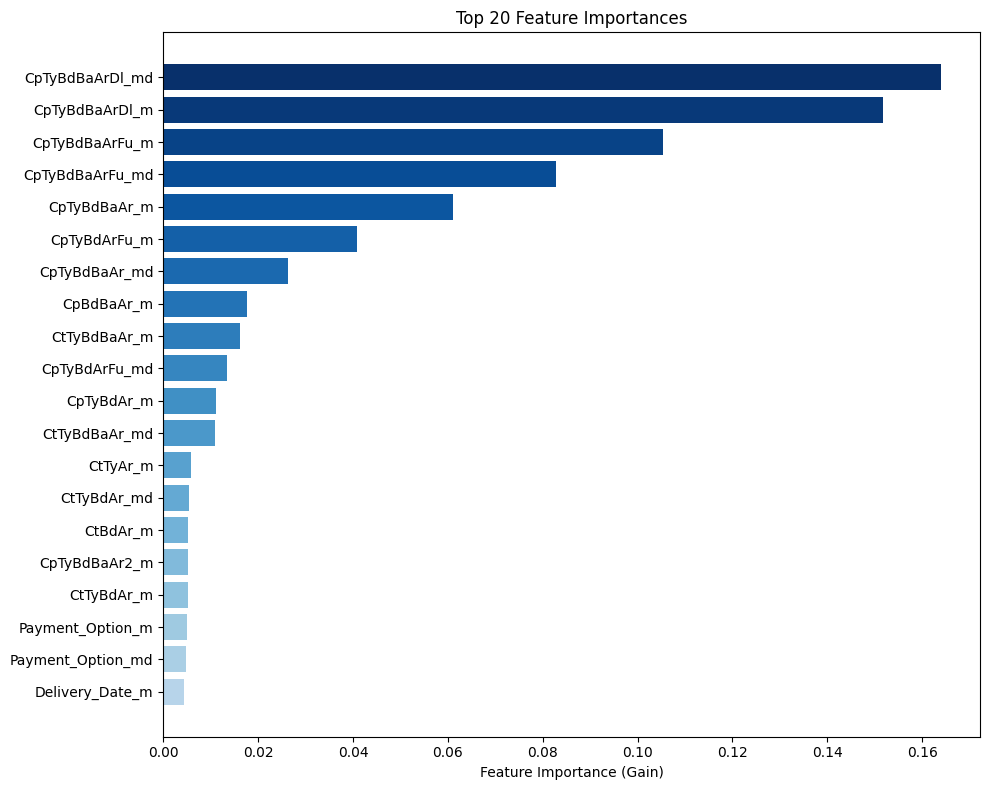

In [9]:
importance = model.feature_importances_
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importance})
feat_imp = feat_imp.sort_values('Importance', ascending=True).tail(20)

plt.figure(figsize=(10, 8))
colors = plt.cm.Blues(np.linspace(0.3, 1, len(feat_imp)))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors)
plt.xlabel('Feature Importance (Gain)')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

## Actual vs Predicted

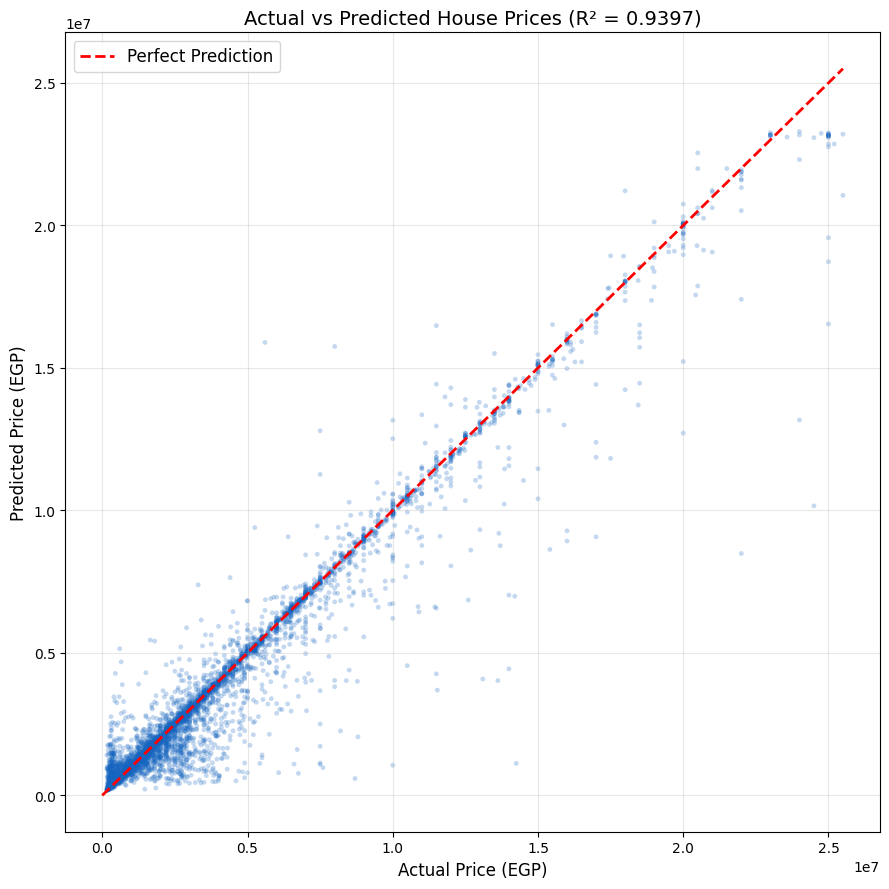

In [10]:
plt.figure(figsize=(9, 9))
plt.scatter(y_actual, y_pred, alpha=0.25, s=12, color='#1565C0', edgecolors='none')
max_val = max(y_actual.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price (EGP)', fontsize=12)
plt.ylabel('Predicted Price (EGP)', fontsize=12)
plt.title(f'Actual vs Predicted House Prices (R² = {r2:.4f})', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##  Residual Analysis

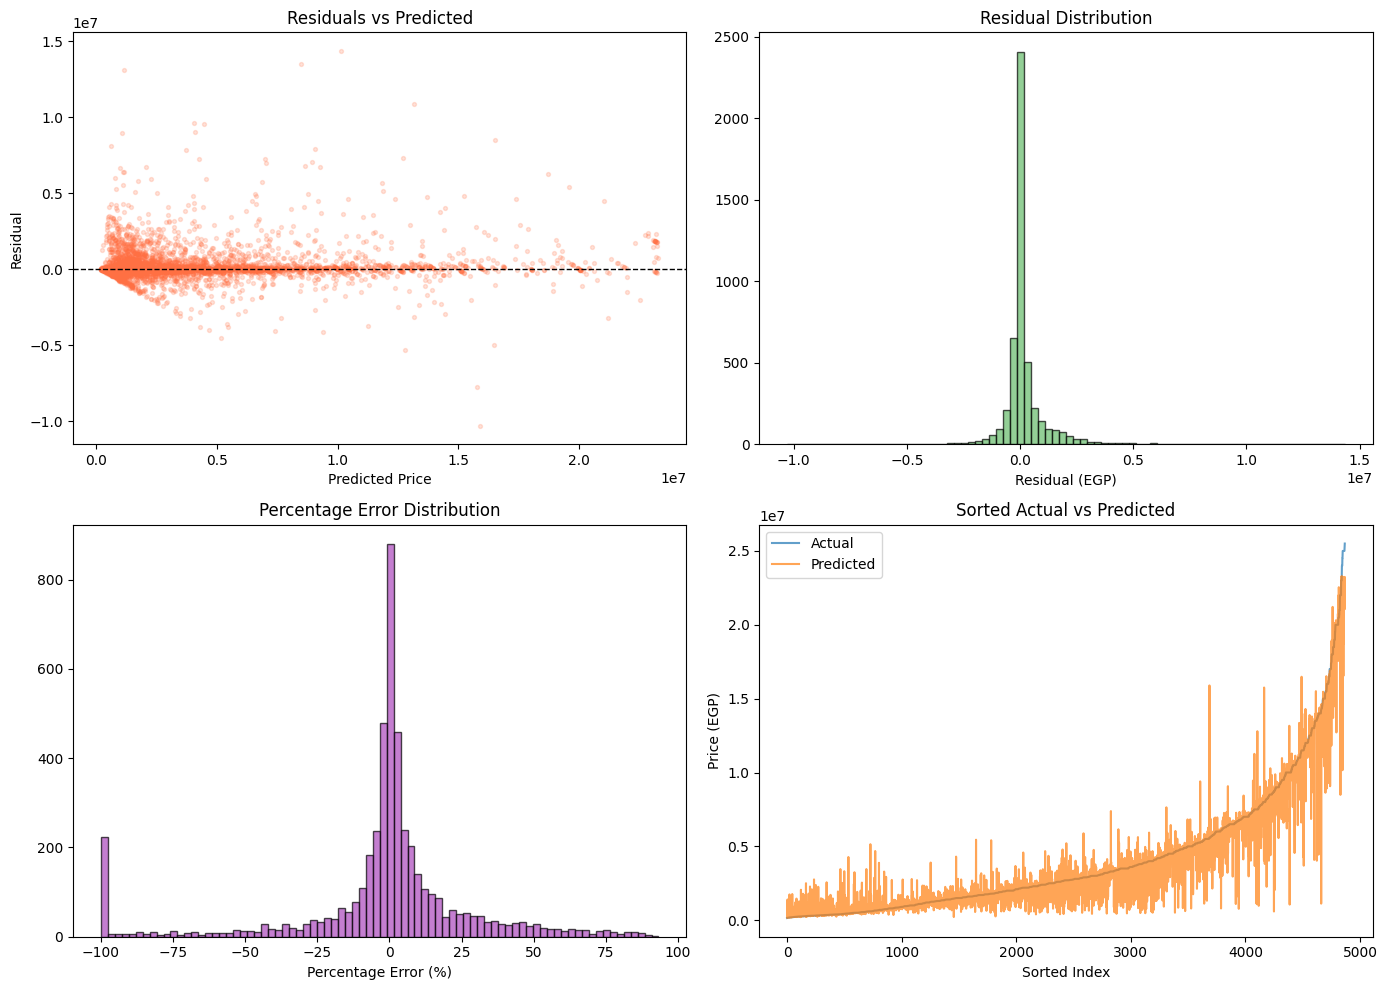

Mean Residual:           199,491 EGP
Std Residual:          1,067,220 EGP
Median |%Error|:            6.8%


In [11]:
residuals = y_actual - y_pred
pct_error = (residuals / y_actual) * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(y_pred, residuals, alpha=0.2, s=8, color='#FF7043')
axes[0, 0].axhline(y=0, color='black', linestyle='--', lw=1)
axes[0, 0].set_xlabel('Predicted Price')
axes[0, 0].set_ylabel('Residual')
axes[0, 0].set_title('Residuals vs Predicted')

axes[0, 1].hist(residuals, bins=80, color='#66BB6A', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Residual (EGP)')
axes[0, 1].set_title('Residual Distribution')

axes[1, 0].hist(pct_error.clip(-100, 100), bins=80, color='#AB47BC', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Percentage Error (%)')
axes[1, 0].set_title('Percentage Error Distribution')

idx = np.argsort(y_actual.values)
axes[1, 1].plot(y_actual.values[idx], label='Actual', alpha=0.7)
axes[1, 1].plot(y_pred[idx], label='Predicted', alpha=0.7)
axes[1, 1].set_xlabel('Sorted Index')
axes[1, 1].set_ylabel('Price (EGP)')
axes[1, 1].set_title('Sorted Actual vs Predicted')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"Mean Residual:   {residuals.mean():>15,.0f} EGP")
print(f"Std Residual:    {residuals.std():>15,.0f} EGP")
print(f"Median |%Error|: {np.median(np.abs(pct_error)):>14.1f}%")